## Weather delay analysis

- How strongly does weather correlate with ATFM arrival delay?
- Which weather variable has the strongest effect?

In [ ]:
# Imports & connections
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import seaborn as sns
from plotly.subplots import make_subplots
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL


# Load .env from /streamlit/
load_dotenv(find_dotenv())


# Connection to DB
def get_engine():
    url = URL.create(
        "postgresql+psycopg2",
        username=os.environ["DB_USER"],
        password=os.environ["DB_PASSWORD"],
        host=os.environ["DB_HOST"],
        port=os.environ["DB_PORT"],
        database=os.environ["DB_NAME"],
    )
    return create_engine(url, pool_pre_ping=True, pool_recycle=1800)

def run_query(query, params=None):
    with get_engine().connect() as conn:
        return pd.read_sql(text(query), conn, params=params or {})

def query(sql, **kwargs):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, **kwargs)

In [ ]:
# Aggregate fact_weather from hourly → daily, then join to fact_airport_delay.
# Aggregation logic per variable:
#   wind_speed      → MAX  (peak wind is operationally relevant, not the daily mean)
#   precipitation   → SUM  (total daily rainfall/snowfall in mm)
#   temperature     → AVG  (less critical, but included for completeness)
#   snow_depth      → MAX  (worst snow situation of the day)
#   cloud_cover     → AVG  (persistent cloudiness)
#
# Only days with >= 20 arrivals are included (removes low-traffic noise).
# Only dates where weather data exists (>= 2019-01-01) are included.

df = run_query("""
WITH weather_daily AS (
    SELECT
        apt_icao,
        ts_hour::date               AS flt_date,
        MAX(wind_speed)             AS wind_max,
        AVG(wind_speed)             AS wind_avg,
        SUM(precipitation)          AS precip_sum,
        AVG(temperature)            AS temp_avg,
        MAX(snow_depth)             AS snow_max,
        AVG(cloud_cover)            AS cloud_avg
    FROM fact_weather
    WHERE ts_hour >= '2019-01-01'
    GROUP BY apt_icao, ts_hour::date
)
SELECT
    d.apt_icao,
    d.flt_date,
    d.flt_arr_1,
    d.dly_apt_arr_1                                         AS dly_total,
    d.dly_apt_arr_1 / NULLIF(d.flt_arr_1, 0)                AS dly_per_flight,
    d.dly_apt_arr_w_1                                       AS dly_weather,
    d.dly_apt_arr_w_1 / NULLIF(d.dly_apt_arr_1, 0) * 100    AS weather_share_pct,
    w.wind_max,
    w.wind_avg,
    w.precip_sum,
    w.temp_avg,
    w.snow_max,
    w.cloud_avg
FROM fact_airport_delay d
JOIN weather_daily w
    ON d.apt_icao = w.apt_icao
    AND d.flt_date = w.flt_date
WHERE d.flt_arr_1 >= 20
  AND d.flt_date >= '2019-01-01'
ORDER BY d.flt_date, d.apt_icao
"""
)

# Clip extreme outliers for cleaner plots
p999 = df["dly_per_flight"].quantile(0.999)

df_clean = df[
    df["dly_per_flight"].isna() | (df["dly_per_flight"] <= p999)
].copy()

df_clean["dly_per_flight"] = df_clean["dly_per_flight"].fillna(0) # NaN means delay 0

print(f"Rows loaded      : {len(df):,}")
print(f"Rows after clip  : {len(df_clean):,}")
print(f"Airports covered : {df_clean['apt_icao'].nunique()}")
print(f"Date range       : {df_clean['flt_date'].min()} → {df_clean['flt_date'].max()}")
df_clean.describe()

Rows loaded      : 314,928
Rows after clip  : 314,759
Airports covered : 193
Date range       : 2019-01-01 → 2026-03-31


,flt_arr_1,dly_total,dly_per_flight,dly_weather,weather_share_pct,wind_max,wind_avg,precip_sum,temp_avg,snow_max,cloud_avg
count,314759.000000,168478.000000,314759.000000,168478.000000,39814.000000,314759.000000,314759.000000,314759.000000,314759.000000,314759.000000,314759.000000
mean,132.442199,171.947833,0.349532,77.797896,27.945291,18.268469,11.781216,2.384003,13.124101,0.022078,58.056634
std,140.877368,726.549990,1.654504,569.999818,43.818308,7.661801,6.024235,5.334722,7.752046,0.143372,31.101332
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.800000,0.375000,0.000000,-24.708333,0.000000,0.000000
25%,40.000000,0.000000,0.000000,0.000000,0.000000,12.600000,7.287500,0.000000,7.495833,0.000000,33.416667
50%,80.000000,0.000000,0.000000,0.000000,0.000000,17.000000,10.445833,0.100000,13.108333,0.000000,62.708333
75%,161.000000,0.000000,0.000000,0.000000,94.049316,22.600000,15.012500,2.300000,18.679167,0.000000,85.458333
max,844.000000,21873.000000,34.400000,21873.000000,100.000000,81.400000,55.675000,154.900000,38.533333,5.250000,100.000000


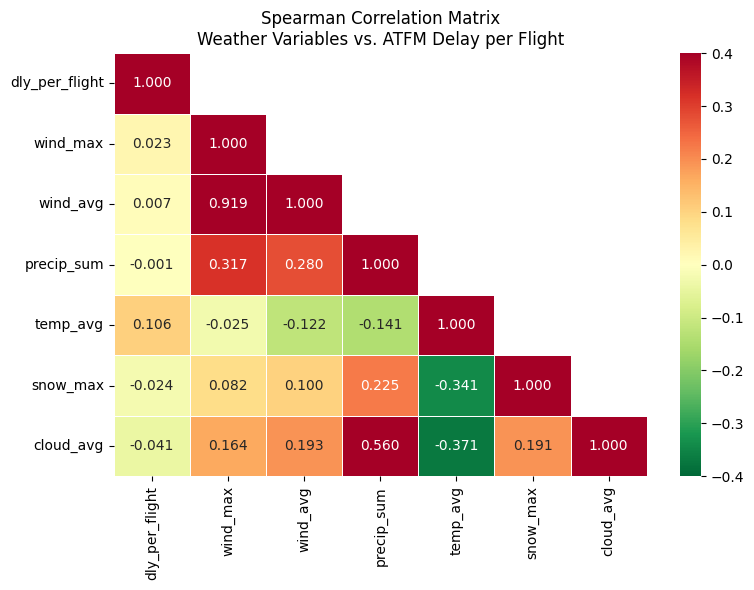

In [3]:
WEATHER_VARS = ["wind_max", "wind_avg", "precip_sum", "temp_avg", "snow_max", "cloud_avg"]
TARGET = "dly_per_flight"

corr_matrix = df_clean[[TARGET] + WEATHER_VARS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    center=0,
    vmin=-0.4, vmax=0.4,
    linewidths=0.5,
    ax=ax,
    mask=mask,
)
ax.set_title("Spearman Correlation Matrix\nWeather Variables vs. ATFM Delay per Flight", fontsize=12)
plt.tight_layout()
plt.show()

The strongest predictor (temp_avg) is not a direct weather effect. It is a proxy for seasonality. Hot days = summer = peak travel season = high traffic volume = more delay. The effect stems not from the weather itself, but from factors correlated with the weather.

The weak correlations with wind and precipitation can be explained by the fact that ATFM delay accounts for only about 30–50% of all delays, and the data aggregates 193 very different airports—meaning a storm in Amsterdam is heavily diluted in the EU average.

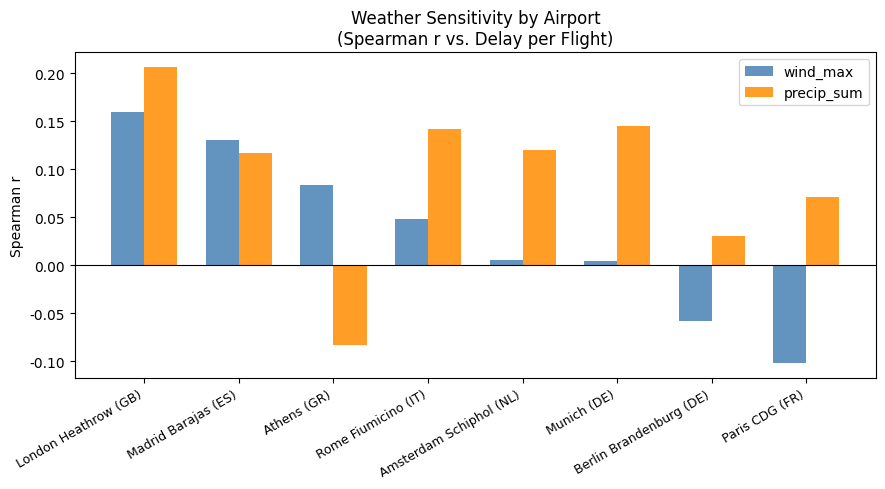

                airport    r_wind  r_precip    n
   London Heathrow (GB)  0.159281  0.206690 2647
    Madrid Barajas (ES)  0.130610  0.116670 2644
            Athens (GR)  0.083884 -0.082699 2646
    Rome Fiumicino (IT)  0.048361  0.141838 2647
Amsterdam Schiphol (NL)  0.005450  0.119717 2624
            Munich (DE)  0.004262  0.144969 2637
Berlin Brandenburg (DE) -0.058024  0.030080 2590
         Paris CDG (FR) -0.102178  0.070628 2647


In [4]:
# Hypothesis: Northern/Atlantic airports (EGLL, EHAM, EDDM) are more
# sensitive to wind and precipitation than Mediterranean airports (LEMD, LIRF).
# Compare Spearman r(wind_max, dly_per_flight) per airport.

FOCUS_AIRPORTS = {
    "EGLL": "London Heathrow (GB)",
    "EHAM": "Amsterdam Schiphol (NL)",
    "EDDM": "Munich (DE)",
    "EDDB": "Berlin Brandenburg (DE)",
    "LEMD": "Madrid Barajas (ES)",
    "LIRF": "Rome Fiumicino (IT)",
    "LGAV": "Athens (GR)",
    "LFPG": "Paris CDG (FR)",
}

apt_results = []
for icao, label in FOCUS_AIRPORTS.items():
    sub = df_clean[df_clean["apt_icao"] == icao][[TARGET, "wind_max", "precip_sum"]].dropna()
    if len(sub) < 50:
        continue
    r_wind,  _ = stats.spearmanr(sub["wind_max"],   sub[TARGET])
    r_precip, _ = stats.spearmanr(sub["precip_sum"], sub[TARGET])
    apt_results.append({"airport": label, "r_wind": r_wind, "r_precip": r_precip, "n": len(sub)})

apt_df = pd.DataFrame(apt_results).sort_values("r_wind", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(apt_df))
w = 0.35

bars1 = ax.bar(x - w/2, apt_df["r_wind"],   width=w, label="wind_max",   color="steelblue", alpha=0.85)
bars2 = ax.bar(x + w/2, apt_df["r_precip"], width=w, label="precip_sum", color="darkorange", alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(apt_df["airport"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Spearman r")
ax.set_title("Weather Sensitivity by Airport\n(Spearman r vs. Delay per Flight)", fontsize=12)
ax.legend()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.show()

print(apt_df.to_string(index=False))

**London Heathrow** dominates on both variables (wind r=0.16, precipitation r=0.21) due to single-runway capacity, Atlantic weather patterns, and no buffer for diversions.

**Madrid** is surprising with r=0.13 (wind) and r=0.12 (precipitation) for a Mediterranean climate. Explanation: Madrid sits on a high plateau (~600m), making it significantly more prone to wind than coastal airports.

**Athens** has a negative precipitation effect (r=-0.08): Rain in Athens mostly falls in winter (off-peak season, low traffic volume), causing the direction to reverse.


**Amsterdam/Schiphol** has near-zero correlation which is surprising for a wind-exposed North Sea airport. However, Schiphol has multiple runways and highly weather-resilient operations. Delays there stem more from capacity constraints than from weather.

**Paris CDG**: negative wind effect (r=-0.10) is likely skewed by the structure of strikes. On strike days, traffic is reduced and weather becomes irrelevant.

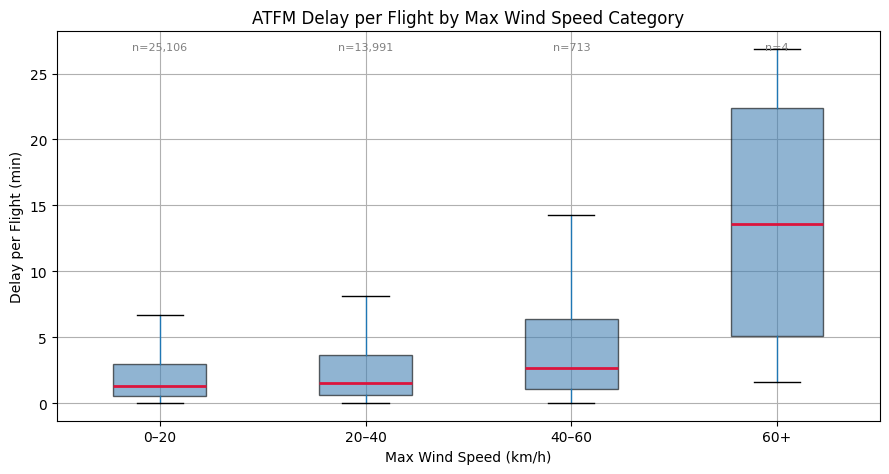

In [5]:
# Bin wind_max into Beaufort-inspired categories (km/h thresholds).
# Box plots are more interpretable in a presentation than scatter + regression.

df_wind = df_clean[df_clean["dly_total"] > 0].copy()

bins = [0, 20, 40, 60, np.inf]
labels = ["0–20", "20–40", "40–60", "60+"]

df_wind["wind_cat"] = pd.cut(
    df_wind["wind_max"], bins=bins, labels=labels, right=False
)

fig, ax = plt.subplots(figsize=(9, 5))

df_wind.boxplot(
    column=TARGET,
    by="wind_cat",
    ax=ax,
    showfliers=False,       # Outliers hidden for readability
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="crimson", linewidth=2),
)

# Overlay sample size per bin
for i, label in enumerate(labels, 1):
    n = df_wind[df_wind["wind_cat"] == label][TARGET].count()
    ax.text(i, ax.get_ylim()[1] * 0.95, f"n={n:,}", ha="center", fontsize=8, color="gray")

ax.set_title("ATFM Delay per Flight by Max Wind Speed Category", fontsize=12)
ax.set_xlabel("Max Wind Speed (km/h)")
ax.set_ylabel("Delay per Flight (min)")
plt.suptitle("")  # Remove automatic pandas boxplot title
plt.tight_layout()
plt.show()

0–20 km/h: Median ~1.5 min, narrow distribution -> normal operation  
20–40 km/h: Median ~1.5 min, little difference -> wind not yet a factor  
40–60 km/h: Median jumps to ~2.5 min, IQR significantly wider -> wind begins to have an effect  
60+ km/h: Median ~13 min, IQR 5–22 min -> strong effect, but only n=4 (not statistically robust)  